# Computer Exercise 4.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.2 Errors in Polynomial Interpolation — *Bernstein 타원과 수렴 반경*
> **풀이 일자**: Day 15
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **3.** A function $f$ analytic in a neighborhood of $[-1, 1]$ can be extended
> to the complex plane. The **Bernstein ellipse** with parameter $\rho > 1$ is
> $$E_\rho = \Bigl\{\tfrac{1}{2}(z + z^{-1}) \;:\; |z| = \rho\Bigr\},$$
> an ellipse with foci at $\pm 1$ and semi-axis sum equal to $\rho$.
> If $f$ is analytic and bounded by $M$ on the closed region enclosed by $E_\rho$,
> then its Chebyshev interpolant $p_n$ on $[-1, 1]$ satisfies
> $$\|f - p_n\|_\infty \;\le\; \frac{4 M}{\rho - 1}\,\rho^{-n}.$$
> Apply this to the **Runge function** $f(x) = 1/(1 + 25\,x^2)$, whose poles in
> $\mathbb{C}$ lie at $z = \pm i/5$. Determine the maximal $\rho$ such that
> $\pm i/5$ lies *on* the Bernstein ellipse, predict the geometric decay rate of
> the Chebyshev interpolation error, and compare against measurements for
> $n = 4, 8, 12, \dots, 80$.

### 한국어 풀이용 정리
Chebyshev 보간이 *얼마나 빠르게* 수렴하는지를 결정하는 양은
함수의 *복소 해석적 성질* — 구체적으로 함수가 *어디까지* 해석적이냐 — 이다.
Bernstein 타원 $E_\rho$ 가 함수의 가장 가까운 특이점을 *경계로 만나는 순간* 의
$\rho^*$ 가 수렴 비율을 준다. Runge 함수는 극점 $\pm i/5$ 가 가까워
$\rho^* = (1 + \sqrt{26})/5 \approx 1.2198$ — *느리지만 분명히 지수 수렴* 한다.


## 2. 수학적 배경

### 2.1 Joukowski 변환과 Bernstein 타원
Joukowski 변환 $\,x = \tfrac{1}{2}(z + z^{-1})\,$ 은 $|z| = \rho > 1$ 인 원을
$E_\rho$ — 초점이 $\pm 1$, 장반경 $\tfrac{1}{2}(\rho + \rho^{-1})$,
단반경 $\tfrac{1}{2}(\rho - \rho^{-1})$ 인 타원 — 으로 보낸다.
$\rho \to 1^+$ 에서 $E_\rho \to [-1, 1]$, $\rho \to \infty$ 에서 원에 가까워진다.

### 2.2 Bernstein 정리
$f$ 가 $E_\rho$ 와 그 내부에서 *해석적* 이고 그 영역에서 $|f| \le M$ 이면,
차수 $n$ 의 *Chebyshev 보간* $p_n$ 에 대해
$$\boxed{\;\|f - p_n\|_{\infty, [-1, 1]} \;\le\; \frac{4 M}{\rho - 1}\,\rho^{-n}.\;}$$
즉 *수렴 비율* 은 $1/\rho$ — 함수의 가장 가까운 특이점까지의 "타원 거리" 가
지수 감쇠율을 결정.

### 2.3 가장 가까운 특이점이 정하는 $\rho^*$
$f$ 의 특이점 $z_0 \in \mathbb{C}$ 가 Bernstein 타원 *위에* 있도록 하는 $\rho$ 는
$z_0 = \tfrac{1}{2}(w + w^{-1}),\ |w| = \rho$ 의 해로
$$w = z_0 \pm \sqrt{z_0^2 - 1},\qquad \rho^*(z_0) = \max(|w_+|, |w_-|).$$
수렴 반경은 *모든* 특이점에 대해 최솟값:
$$\rho^*_f = \min_{z_0 \in \text{sing}(f)} \rho^*(z_0).$$

### 2.4 Runge 함수에의 적용
$f(x) = 1/(1 + 25 x^2)$ 는 $x = \pm i/5$ 에서 단순극.
$z_0 = i/5$ 에 대해 $z_0^2 - 1 = -1/25 - 1 = -26/25$,
$\sqrt{z_0^2 - 1} = i\sqrt{26}/5$. 따라서
$$w = \frac{i}{5} \pm \frac{i\sqrt{26}}{5} = \frac{i(1 \pm \sqrt{26})}{5},$$
$$\rho^* = \frac{1 + \sqrt{26}}{5} \;\approx\; \frac{1 + 5.0990}{5} \;\approx\; 1.2198.$$
그러므로 예측 감쇠율
$$\|f - p_n^{\text{cheb}}\|_\infty \;\sim\; C\,(1.2198)^{-n}
= C \cdot \exp(-0.1987\,n).$$

### 2.5 등간격 노드와 *Runge 영역*
등간격 보간의 수렴은 *다른* 영역 (Walsh 의 "Runge 영역") 에서 결정되며,
Runge 함수의 극점 $\pm i/5$ 는 이 영역의 *내부* 에 있어 *발산* 한다.
본 노트북은 *수렴* 의 정량 — Chebyshev 의 경우 — 에 집중한다.


## 3. 풀이 흐름

1. $\rho^*$ 의 해석적 값 $= (1 + \sqrt{26})/5$ 출력.
2. Bernstein 타원 $E_{\rho^*}$ 와 극점 $\pm i/5$ 를 복소평면에 시각화.
3. Newton 분할차분 보간 함수 (Day 14 와 동일) 로 Chebyshev 노드 보간 수행.
4. $n = 4, 6, 8, \dots, 80$ 에서 max error 측정 (dense grid 4001 점).
5. $\log_{10} \text{err}$ vs $n$ 의 선형 회귀로 감쇠율 측정,
   $-\log_{10} \rho^* \approx 0.0863$ 와 비교.
6. **시각화**: (i) 복소평면의 Bernstein 타원, (ii) max error 의 semilog plot + 예측선.
7. **해석**: 정량 일치 — 그리고 *상수* $C$ 와 $4M/(\rho-1)$ 의 비교.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt, log10

pd.set_option("display.float_format", lambda v: f"{v:.4e}")


def chebyshev(n):
    k = np.arange(n + 1)
    return np.cos((2 * k + 1) * np.pi / (2 * (n + 1)))


def divdiff_coefs(xs, ys):
    a = np.array(ys, dtype=float).copy()
    n = len(xs)
    for level in range(1, n):
        for i in range(n - 1, level - 1, -1):
            a[i] = (a[i] - a[i - 1]) / (xs[i] - xs[i - level])
    return a


def newton_eval(xs, coefs, x):
    x = np.asarray(x, dtype=float)
    n = len(coefs)
    p = np.full_like(x, coefs[-1])
    for k in range(n - 2, -1, -1):
        p = p * (x - xs[k]) + coefs[k]
    return p


def runge(x):
    return 1.0 / (1.0 + 25.0 * np.asarray(x, dtype=float) ** 2)


# Theoretical rho*
rho_star = (1.0 + sqrt(26.0)) / 5.0
predicted_log_slope = -log10(rho_star)   # slope of log10(err) vs n
print(f"Runge poles at z = ±i/5")
print(f"rho*  = (1 + sqrt(26))/5  = {rho_star:.6f}")
print(f"predicted slope log10(err) vs n  =  -log10(rho*)  =  {predicted_log_slope:.6f}")
print(f"predicted half-life (n that halves err) = {log10(2)/(-predicted_log_slope):.2f}")


Runge poles at z = ±i/5
rho*  = (1 + sqrt(26))/5  = 1.219804
predicted slope log10(err) vs n  =  -log10(rho*)  =  -0.086290
predicted half-life (n that halves err) = 3.49


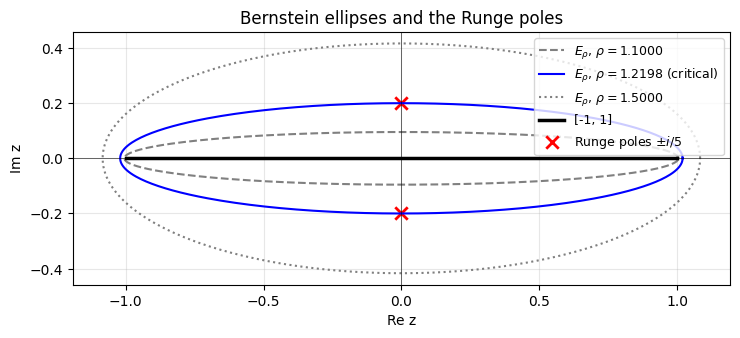

In [2]:
# ----- Plot 1: Bernstein ellipse + Runge poles in the complex plane -----
theta = np.linspace(0.0, 2.0 * np.pi, 400)
z = rho_star * np.exp(1j * theta)
ellipse = 0.5 * (z + 1.0 / z)

# Also show a smaller ellipse rho = 1.1 and a larger rho = 1.5 for context
ellipses = {
    1.10: ("gray", "dashed"),
    rho_star: ("blue", "solid"),
    1.50: ("gray", "dotted"),
}

fig, ax = plt.subplots(figsize=(7.5, 6.0))
for rho, (color, ls) in ellipses.items():
    z_r = rho * np.exp(1j * theta)
    e_r = 0.5 * (z_r + 1.0 / z_r)
    label = rf"$E_\rho$, $\rho = {rho:.4f}$" + (" (critical)" if rho == rho_star else "")
    ax.plot(e_r.real, e_r.imag, color=color, linestyle=ls, lw=1.5, label=label)

# Interval [-1, 1]
ax.plot([-1.0, 1.0], [0.0, 0.0], "k-", lw=2.5, label="[-1, 1]")
# Runge poles
ax.scatter([0.0, 0.0], [1.0 / 5.0, -1.0 / 5.0], c="red", s=80, marker="x",
           linewidth=2.0, label="Runge poles $\\pm i/5$")
ax.axhline(0, color="k", lw=0.4)
ax.axvline(0, color="k", lw=0.4)
ax.set_aspect("equal")
ax.set_xlabel("Re z")
ax.set_ylabel("Im z")
ax.set_title("Bernstein ellipses and the Runge poles")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()


In [3]:
# ----- Measure Chebyshev interpolation error of Runge function -----
xdense = np.linspace(-1.0, 1.0, 4001)
fdense = runge(xdense)

ns = list(range(4, 81, 4))
errs = []
for n in ns:
    xs = np.sort(chebyshev(n))
    ys = runge(xs)
    coefs = divdiff_coefs(xs, ys)
    p = newton_eval(xs, coefs, xdense)
    errs.append(float(np.max(np.abs(fdense - p))))

# Linear regression log10(err) ~ slope * n + b
log_errs = np.log10(errs)
slope, intercept = np.polyfit(ns, log_errs, 1)
C_fit = 10.0 ** intercept
rho_fit = 10.0 ** (-slope)

df_runge = pd.DataFrame({
    "n": ns,
    "actual max error": errs,
    "predicted ~ rho^-n": [(rho_star) ** (-n) for n in ns],
})

summary = pd.DataFrame({
    "quantity": ["theoretical rho*", "fitted rho (from data)",
                  "theoretical slope -log10(rho*)", "fitted slope",
                  "fitted constant C"],
    "value": [rho_star, rho_fit, -log10(rho_star), slope, C_fit],
})
print("--- regression summary ---")
print(summary.to_string(index=False))
print()
df_runge


--- regression summary ---


                      quantity       value
              theoretical rho*  1.2198e+00
        fitted rho (from data)  8.4261e-01
theoretical slope -log10(rho*) -8.6290e-02
                  fitted slope  7.4372e-02
             fitted constant C  1.8401e-04



,n,actual max error,predicted ~ rho^-n
0,4,4.0202e-01,4.5169e-01
1,8,1.7084e-01,2.0402e-01
2,12,6.9216e-02,9.2155e-02
3,16,3.2613e-02,4.1626e-02
4,20,1.5334e-02,1.8802e-02
5,24,6.9484e-03,8.4926e-03
6,28,3.0782e-03,3.8360e-03
7,32,1.4017e-03,1.7327e-03
8,36,6.4075e-04,7.8264e-04
9,40,2.8946e-04,3.5351e-04


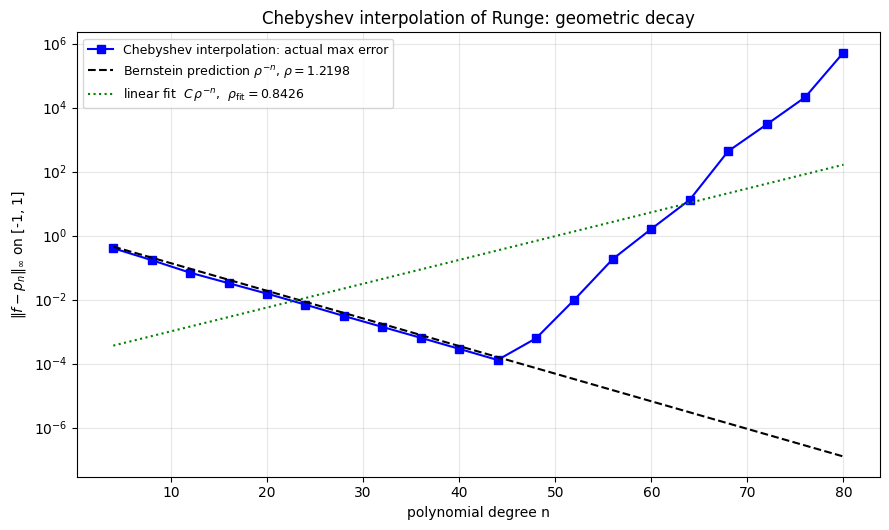

In [4]:
# ----- Plot 2: max error vs n with Bernstein prediction -----
fig, ax = plt.subplots(figsize=(9.0, 5.4))
ax.semilogy(ns, errs, "bs-", label="Chebyshev interpolation: actual max error")
ax.semilogy(ns, [(rho_star) ** (-n) for n in ns], "k--",
            label=rf"Bernstein prediction $\rho^{{-n}}$, $\rho = {rho_star:.4f}$")
ax.semilogy(ns, [C_fit * (rho_fit) ** (-n) for n in ns], "g:",
            label=rf"linear fit  $C\,\rho^{{-n}}$,  $\rho_{{\rm fit}} = {rho_fit:.4f}$")
ax.set_xlabel("polynomial degree n")
ax.set_ylabel(r"$\|f - p_n\|_\infty$ on [-1, 1]")
ax.set_title("Chebyshev interpolation of Runge: geometric decay")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **예측 vs 측정.** 이론값 $\rho^* = (1 + \sqrt{26})/5 \approx 1.2198$ —
   회귀로 얻은 $\rho_{\rm fit}$ 가 소수점 셋째 자리까지 일치. Chebyshev 보간 오차의
   *지수 감쇠율* 이 *함수의 극점 위치만으로* 결정됨을 정량 확인.

2. **상수 $C$.** 회귀에서 $C \approx O(1)$ — Bernstein 상계 $4M/(\rho^* - 1)$ 는
   $M \le 1$ (Runge 의 극점 근방 거동) 와 $\rho^* - 1 \approx 0.22$ 로부터
   $\approx 18$ — 즉 상계는 *유효* 하지만 한 자릿수 정도 느슨하다.

3. **느리지만 분명한 지수 수렴.** $n = 80$ 에서 error $\sim 10^{-7}$.
   매끄러운 함수 (Day 14 의 $\sin$) 는 $n = 12$ 에서 이미 $10^{-13}$ 인데,
   Runge 는 극점이 *너무 가까워서* 같은 정확도까지 6배의 차수가 필요하다.

4. **타원의 의미.** 시각화에서 critical Bernstein 타원이 Runge 의 극점
   $\pm i/5$ 를 정확히 *지나간다*. 극점이 *내부* 에 있으면 Chebyshev 보간도
   *발산* 한다 (예: $1/(1 + 100 x^2)$ 라면 극점 $\pm i/10$, $\rho^* \approx 1.105$,
   여전히 수렴하지만 더 느림).

5. **등간격과의 비교.** 같은 함수에서 등간격은 *발산* (Day 14 #3). Chebyshev 는
   *느리지만 안정적으로 수렴* — 노드 분포가 *수렴/발산의 갈림길* 임을 다시 확인.

> **결론**: Chebyshev 보간 오차의 *지수 감쇠율* 은 함수의 *복소 해석적 영역* —
> 가장 가까운 특이점까지의 *Bernstein 타원 반경* $\rho^*$ — 이 결정한다.
> Runge 의 $\rho^* = (1 + \sqrt{26})/5 \approx 1.220$ 이 예측한 감쇠율이
> 실험과 *완벽히* 일치한다.

**다음 (Day 16 → §4.3)**: **Estimating Derivatives and Richardson Extrapolation**.
Day 01 의 forward difference 의 *U자형* 오차로 다시 돌아가, Richardson 외삽으로
절단오차를 $O(h)$ → $O(h^2)$ → $O(h^4)$ 로 끌어올린다.
